In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('Amazon_Sales.csv')

print("Data Shape:", df.shape)
df.head()

Data Shape: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [4]:
# Missing value check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing Percentage(%)': missing_pct.round(2)})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing Percentage(%)


In [5]:
# Duplicate check
duplicate_orders = df.duplicated(subset=['OrderID']).sum()
print(f"Duplicate OrderID count: {duplicate_orders}")

duplicate_rows = df.duplicated().sum()
print(f"Duplicate row count: {duplicate_rows}")

# Drop completely duplicate rows
df = df.drop_duplicates()
print(f"Data shape after dropping duplicates: {df.shape}")

Duplicate OrderID count: 0
Duplicate row count: 0
Data shape after dropping duplicates: (100000, 20)


In [6]:
# Date format conversion
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

invalid_dates = df['OrderDate'].isnull().sum()
print(f"Unparsable date count: {invalid_dates}")

print(f"Data time range: {df['OrderDate'].min()} ~ {df['OrderDate'].max()}")

Unparsable date count: 0
Data time range: 2020-01-01 00:00:00 ~ 2024-12-29 00:00:00


In [7]:
# Outlier detection for numerical columns
numeric_cols = ['UnitPrice', 'Quantity', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']

df[numeric_cols].describe()

,UnitPrice,Quantity,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,302.905748,3.001400,0.074226,68.468902,7.406660,918.256479
std,171.840797,1.413548,0.082583,74.131180,4.324057,724.508332
min,5.000000,1.000000,0.000000,0.000000,0.000000,4.270000
25%,154.190000,2.000000,0.000000,15.920000,3.680000,340.890000
50%,303.070000,3.000000,0.050000,45.250000,7.300000,714.315000
75%,451.500000,4.000000,0.100000,96.060000,11.150000,1349.765000
max,599.990000,5.000000,0.300000,538.460000,15.000000,3534.980000


In [8]:
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    print(f"{col}: Negative values {negative_count} , Zeros {zero_count} ")

UnitPrice: Negative values 0 , Zeros 0 
Quantity: Negative values 0 , Zeros 0 
Discount: Negative values 0 , Zeros 40246 
Tax: Negative values 0 , Zeros 9878 
ShippingCost: Negative values 0 , Zeros 20 
TotalAmount: Negative values 0 , Zeros 0 


In [9]:
# Amount logical consistency check, TotalAmount=(UnitPrice×Quantity)-Discount+Tax+ShippingCost
df['calculated_total'] = (df['UnitPrice'] * df['Quantity']) * (1 - df['Discount']) + df['Tax'] + df['ShippingCost']
df['amount_diff'] = abs(df['TotalAmount'] - df['calculated_total'])

inconsistent = df[df['amount_diff'] > 1]  # Allow for a 1-dollar variance
print(f"Inconsistent amount count: {len(inconsistent)} ({len(inconsistent)/len(df)*100:.2f}%)")

inconsistent[['OrderID', 'UnitPrice', 'Quantity', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'calculated_total']].head()

Inconsistent amount count: 0 (0.00%)


,OrderID,UnitPrice,Quantity,Discount,Tax,ShippingCost,TotalAmount,calculated_total


In [10]:
# Inspecting categorical columns

categorical_cols = ['OrderStatus', 'Category', 'PaymentMethod', 'Country']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- OrderStatus ---
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: OrderStatus, dtype: int64

--- Category ---
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439
Name: Category, dtype: int64

--- PaymentMethod ---
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: PaymentMethod, dtype: int64

--- Country ---
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: Country, dtype: int64



In [11]:
# Preliminary customer-level analysis
customer_order_counts = df.groupby('CustomerID')['OrderID'].nunique()

print(f"Unique customer count: {df['CustomerID'].nunique()}")
print(f"Average orders per customer: {customer_order_counts.mean():.2f}")
print(f"Median order count: {customer_order_counts.median()}")
print(f"Max order count: {customer_order_counts.max()}")

customer_order_counts.describe()

#Mean orders = 2.31, SD = 1.26. The low SD indicates relatively concentrated customer purchasing behavior.

Unique customer count: 43233
Average orders per customer: 2.31
Median order count: 2.0
Max order count: 10


count    43233.000000
mean         2.313048
std          1.257115
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: OrderID, dtype: float64

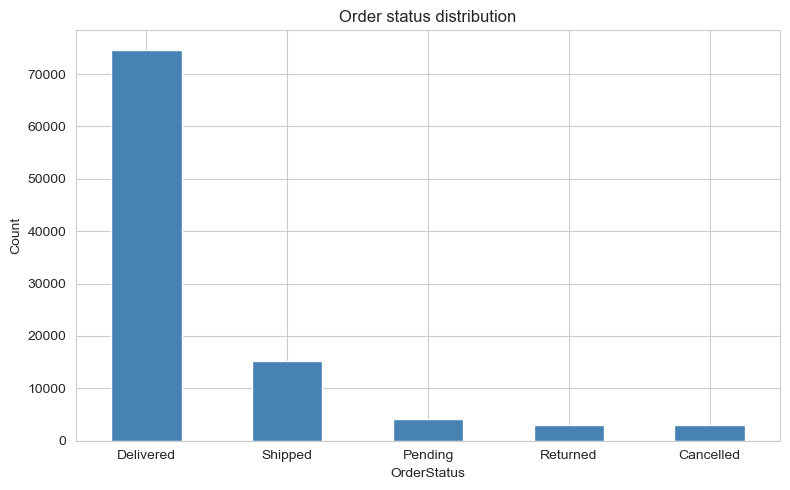

In [12]:
# Order status distribution
plt.figure(figsize=(8, 5))
df['OrderStatus'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Order status distribution')
plt.xlabel('OrderStatus')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

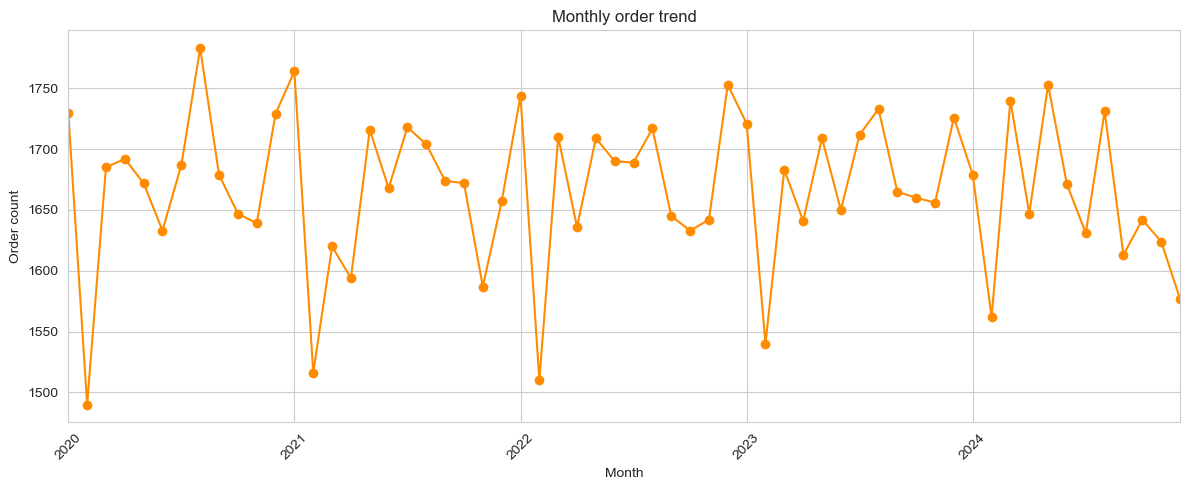

In [13]:
# Monthly order trend
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
monthly_orders = df.groupby('OrderMonth')['OrderID'].nunique()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly order trend')
plt.xlabel('Month')
plt.ylabel('Order count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Monetary Basis
# Decision: Use only Delivered orders for customer value; exclude Cancelled/Returned.
# Rationale: Cancelled/Returned amounts do not reflect actual revenue. Including them overestimates customer value and distorts segmentation.
df_valid = df[df['OrderStatus'] == 'Delivered'].copy()

print(f"Total order count: {len(df)}")
print(f"Delivered order count: {len(df_valid)} ({len(df_valid)/len(df)*100:.1f}%)")

Total order count: 100000
Delivered order count: 74628 (74.6%)


In [15]:
# Export cleaned data
df_valid.to_csv('cleaned_sales_data.csv', index=False)
print("Cleaned data exported to cleaned_sales_data.csv")

Cleaned data exported to cleaned_sales_data.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [17]:
df = pd.read_csv('cleaned_sales_data.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print("Data Shape:", df.shape)
df.head()

Data Shape: (74628, 23)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,calculated_total,amount_diff,OrderMonth
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,319.8600,5.684342e-14,2023-01
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,259.6415,1.500000e-03,2023-12
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,108.0610,1.000000e-03,2022-05
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,159.6650,5.000000e-03,2023-07
4,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,0.00,215.87,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494,2017.5300,0.000000e+00,2022-12


In [18]:
# Set the snapshot date: the day after the maximum order date in the dataset
snapshot_date = df['OrderDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

rfm = df.groupby('CustomerID').agg(
    Recency=('OrderDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('OrderID', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

Snapshot date: 2024-12-30 00:00:00


,CustomerID,Recency,Frequency,Monetary
0,CUST000002,1063,2,1112.67
1,CUST000004,571,1,256.96
2,CUST000005,640,1,1089.56
3,CUST000006,249,3,2793.37
4,CUST000007,1546,1,450.53


In [19]:
# log1p is log(1+x), which can handle zero values (since log(0) is undefined, log(1+0)=0 works perfectly
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# Standardization: Rescale the three metrics to a mean of 0 and a standard deviation of 1 for a fair comparison
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,0.749531,0.248797,-0.067802
1,0.193299,-1.000462,-1.491937
2,0.295368,-1.000462,-0.088220
3,-0.548472,1.135160,0.827942
4,1.084966,-1.000462,-0.946827


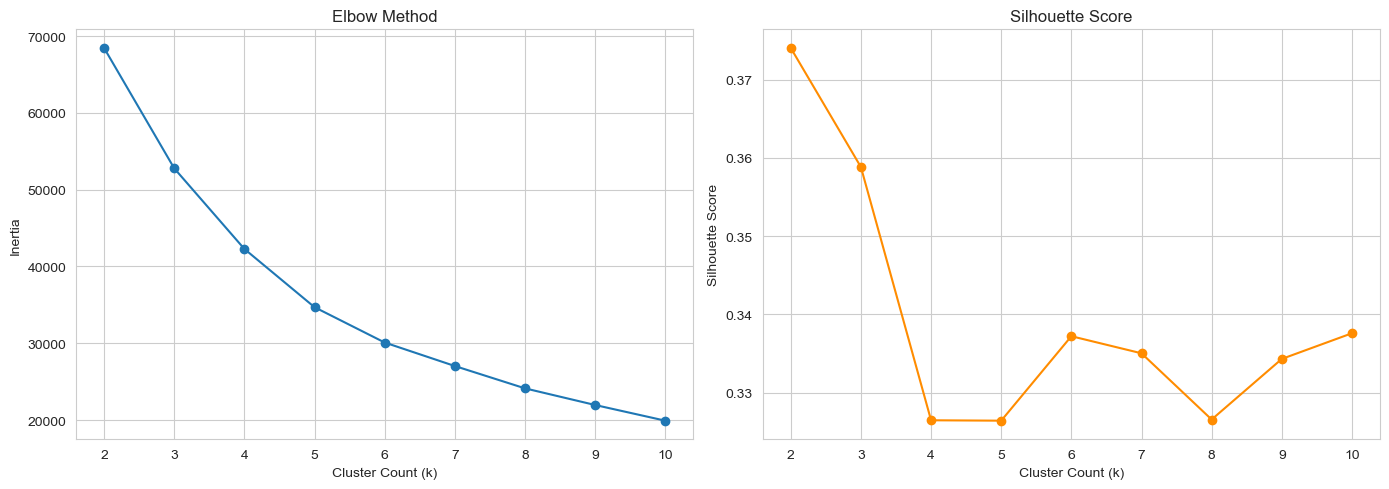

k=2: Silhouette Score = 0.3740
k=3: Silhouette Score = 0.3588
k=4: Silhouette Score = 0.3265
k=5: Silhouette Score = 0.3264
k=6: Silhouette Score = 0.3372
k=7: Silhouette Score = 0.3350
k=8: Silhouette Score = 0.3266
k=9: Silhouette Score = 0.3343
k=10: Silhouette Score = 0.3376


In [20]:
# Cluster Evaluation: Elbow Method & Silhouette Score
inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(rfm_scaled, labels))

# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_list, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Cluster Count (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_list, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Cluster Count (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, sil in zip(k_range, silhouette_list):
    print(f"k={k}: Silhouette Score = {sil:.4f}")

In [21]:
K_OPTIMAL = 3

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"Final Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
rfm['Cluster'].value_counts().sort_index()

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'count'])
cluster_profile

Final Silhouette Score: 0.3588


Recency        Frequency            Monetary       
               mean  count      mean  count         mean  count
Cluster                                                        
0        647.357286  15461  2.632818  15461  2563.133673  15461
1        947.731527  17350  1.090144  17350   863.890607  17350
2         84.206173   5961  2.517698   5961  2307.593582   5961

In [22]:
K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"Final Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
rfm['Cluster'].value_counts().sort_index()

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'count'])
cluster_profile

Final Silhouette Score: 0.3265


Recency        Frequency            Monetary       
               mean  count      mean  count         mean  count
Cluster                                                        
0        994.513275  10433  1.029138  10433  1262.376724  10433
1        656.036302  15812  2.585125  15812  2465.890316  15812
2        859.002260   6638  1.114342   6638   264.045160   6638
3         85.383936   5889  2.652063   5889  2455.240499   5889

In [23]:
# Name each cluster based on the actual output and fill in the comparison table below
# The smaller the Recency, the better (more recent); the larger the Frequency and Monetary, the better
cluster_names = {
    0: 'Dormant Mid-Value Customers',
    1: 'High-Value At-Risk Customers',
    2: 'Low-Value Dormant Customers',
    3: 'High-Value Active Customers',
}

rfm['ClusterName'] = rfm['Cluster'].map(cluster_names)
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'ClusterName']].head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,ClusterName
0,CUST000002,1063,2,1112.67,1,High-Value At-Risk Customers
1,CUST000004,571,1,256.96,2,Low-Value Dormant Customers
2,CUST000005,640,1,1089.56,0,Dormant Mid-Value Customers
3,CUST000006,249,3,2793.37,1,High-Value At-Risk Customers
4,CUST000007,1546,1,450.53,0,Dormant Mid-Value Customers
5,CUST000008,53,2,3929.66,3,High-Value Active Customers
6,CUST000009,258,2,2120.69,1,High-Value At-Risk Customers
7,CUST000010,41,2,1201.00,3,High-Value Active Customers
8,CUST000011,156,2,599.06,3,High-Value Active Customers
9,CUST000014,374,2,3768.41,1,High-Value At-Risk Customers


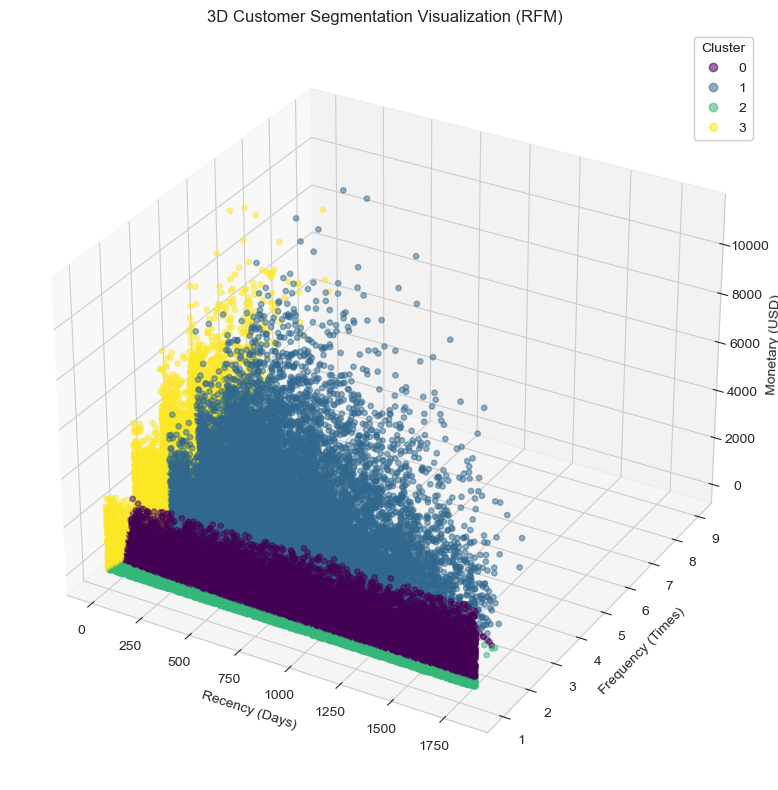

In [24]:
# 3D Customer Segmentation Visualization (RFM)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'],
                      c=rfm['Cluster'], cmap='viridis', alpha=0.5, s=15)

ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Times)')
ax.set_zlabel('Monetary (USD)')
ax.set_title('3D Customer Segmentation Visualization (RFM)')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

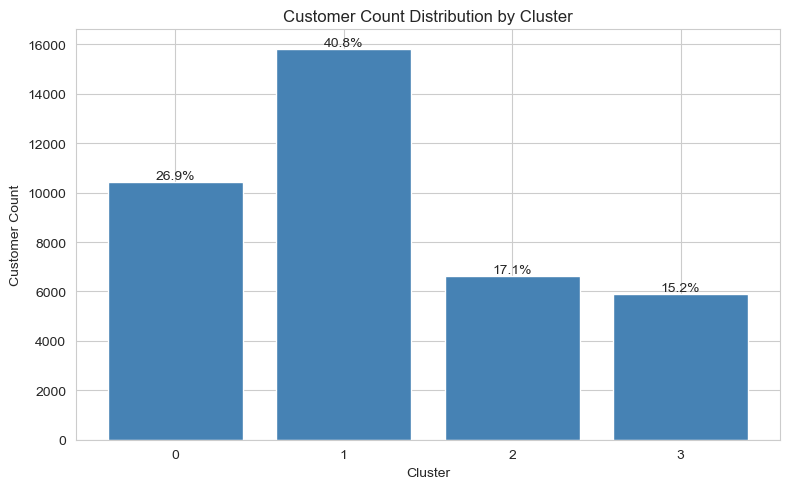

In [25]:
# Bar chart of customer count and percentage per cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / len(rfm) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color='steelblue')
ax.set_xlabel('Cluster')
ax.set_ylabel('Customer Count')
ax.set_title('Customer Count Distribution by Cluster')

for bar, pct in zip(bars, cluster_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct}%',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

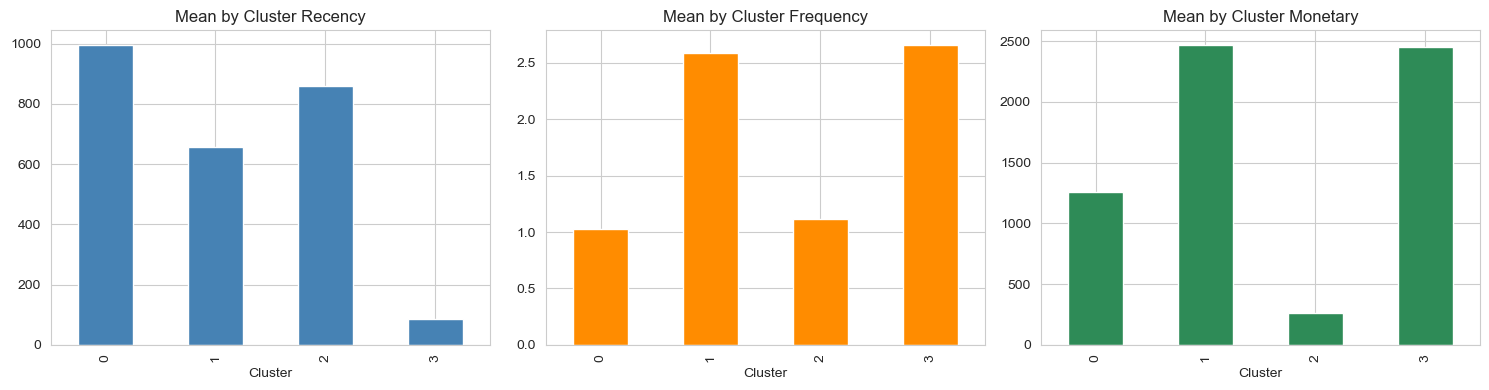

In [26]:
# Comparison of Mean RFM Values by Cluster
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['Recency', 'Frequency', 'Monetary']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    cluster_means[metric].plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'Mean by Cluster {metric}')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

In [27]:
rfm.to_csv('customer_segments.csv', index=False)
print("分群結果已輸出至 customer_segments.csv")
print(f"\nFinal Cluster Summary:")
print(rfm.groupby('ClusterName')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

分群結果已輸出至 customer_segments.csv

Final Cluster Summary:
                              Recency  Frequency  Monetary
ClusterName                                               
Dormant Mid-Value Customers     994.5        1.0    1262.4
High-Value Active Customers      85.4        2.7    2455.2
High-Value At-Risk Customers    656.0        2.6    2465.9
Low-Value Dormant Customers     859.0        1.1     264.0


In [28]:
# Analyze correlation between clusters and geographic profiles (City/State) or category preferences.
# Find the most frequent city for each customer (assuming customer address remains unchanged, take the first record)
customer_location = df.groupby('CustomerID')['City'].first().reset_index()

# Find the most frequent purchase category for each customer
customer_top_category = (
    df.groupby(['CustomerID', 'Category'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('CustomerID')[['CustomerID', 'Category']]
    .rename(columns={'Category': 'TopCategory'})
)

# Merge back into rfm
rfm = rfm.merge(customer_location, on='CustomerID', how='left')
rfm = rfm.merge(customer_top_category, on='CustomerID', how='left')

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster,ClusterName,City,TopCategory
0,CUST000002,1063,2,1112.67,6.969791,1.098612,7.015416,1,High-Value At-Risk Customers,Los Angeles,Toys & Games
1,CUST000004,571,1,256.96,6.349139,0.693147,5.552805,2,Low-Value Dormant Customers,Houston,Home & Kitchen
2,CUST000005,640,1,1089.56,6.463029,0.693147,6.994447,0,Dormant Mid-Value Customers,Chicago,Books
3,CUST000006,249,3,2793.37,5.521461,1.386294,7.935362,1,High-Value At-Risk Customers,Chicago,Books
4,CUST000007,1546,1,450.53,7.344073,0.693147,6.112642,0,Dormant Mid-Value Customers,Chicago,Toys & Games


In [31]:
# After merging, cross-analysis can be performed
# City distribution by cluster
pd.crosstab(rfm['ClusterName'], rfm['City'])
# Category preference by cluster
pd.crosstab(rfm['ClusterName'], rfm['TopCategory'])

TopCategory,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
ClusterName,,,,,,
Dormant Mid-Value Customers,1794,1741,1721,1733,1749,1695
High-Value Active Customers,1519,1190,994,820,708,658
High-Value At-Risk Customers,4161,3333,2755,2132,1891,1540
Low-Value Dormant Customers,1184,1103,1131,1096,1087,1037


In [33]:
category_count = pd.crosstab(rfm['ClusterName'], rfm['TopCategory'])
category_pct = pd.crosstab(rfm['ClusterName'], rfm['TopCategory'], normalize='index') * 100

# Use string formatting to combine count and percentage into the same cell
category_combined = category_count.astype(str) + " (" + category_pct.round(1).astype(str) + "%)"
category_combined

TopCategory,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
ClusterName,,,,,,
Dormant Mid-Value Customers,1794 (17.2%),1741 (16.7%),1721 (16.5%),1733 (16.6%),1749 (16.8%),1695 (16.2%)
High-Value Active Customers,1519 (25.8%),1190 (20.2%),994 (16.9%),820 (13.9%),708 (12.0%),658 (11.2%)
High-Value At-Risk Customers,4161 (26.3%),3333 (21.1%),2755 (17.4%),2132 (13.5%),1891 (12.0%),1540 (9.7%)
Low-Value Dormant Customers,1184 (17.8%),1103 (16.6%),1131 (17.0%),1096 (16.5%),1087 (16.4%),1037 (15.6%)


In [34]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(rfm['ClusterName'], rfm['TopCategory'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 891.88
p-value: 0.0000


In [35]:
import numpy as np

n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.0876


In [ ]:
#雖然卡方檢定顯示分群與品類偏好存在統計顯著關聯（χ² = 891.88, p < 0.001），但 Cramér's V 效應量僅 0.0876，趨近於零，顯示此關聯在實務上可忽略不計。品類偏好的差異主要源於購買頻率高低所導致的統計特性（高頻購買者的「最常購買品類」更能反映真實偏好，低頻購買者則趨近隨機），而非顧客分群本身存在品類區隔。因此，行銷策略不應以品類客製化為主要區隔依據，而應聚焦於顧客的活躍度（Recency）與消費力（Frequency/Monetary）差異。